In [1]:
import numpy as np
import os
import PIL
import PIL.Image
import tensorflow as tf
import tensorflow_datasets as tfds

In [2]:
dataset = '/content/drive/MyDrive/merged_images.zip'

In [3]:
import zipfile

# Define the path to the zip file
zip_file_path = dataset

# Define the directory where images will be extracted
extract_dir = '/content/merged_images/extracted_images'
os.makedirs(extract_dir, exist_ok=True)

# Unzip the file
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

print(f"Images extracted to: {extract_dir}")

Images extracted to: /content/merged_images/extracted_images


Now, let's load the images using `tf.keras.utils.image_dataset_from_directory`. Assuming the images are organized into subdirectories representing classes, or directly in the extracted folder.

In [4]:
batch_size = 32
img_height = 180
img_width = 180

train_ds = tf.keras.utils.image_dataset_from_directory(
  '/content/merged_images/extracted_images/merged_images',
  validation_split=0.2,
  subset="training",
  seed=123,
  image_size=(img_height, img_width),
  batch_size=batch_size,
  color_mode='grayscale')

Found 129975 files belonging to 4 classes.
Using 103980 files for training.


In [5]:
val_test_ds = tf.keras.utils.image_dataset_from_directory(
    '/content/merged_images/extracted_images/merged_images',
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size,
    color_mode="grayscale",
    shuffle=True
)

val_batches = tf.data.experimental.cardinality(val_test_ds)
test_ds = val_test_ds.take(val_batches // 2)
val_ds = val_test_ds.skip(val_batches // 2)

Found 129975 files belonging to 4 classes.
Using 25995 files for validation.


In [6]:
class_names = train_ds.class_names
print(class_names)

['MildDemented', 'ModerateDemented', 'NonDemented', 'VeryMildDemented']


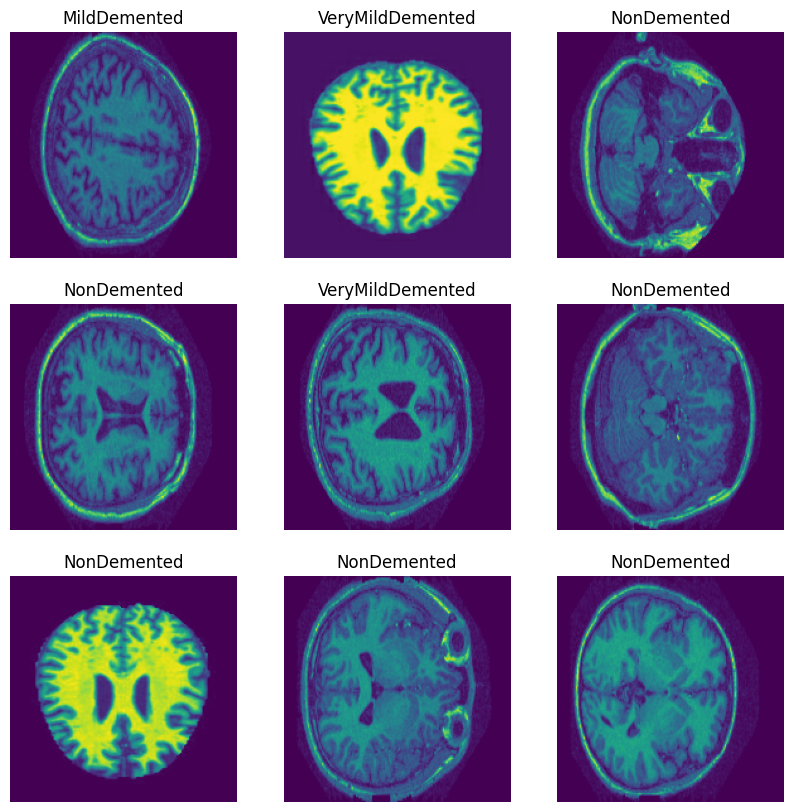

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
  for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names[labels[i]])
    plt.axis("off")

In [8]:
for image_batch, labels_batch in train_ds:
  print(image_batch.shape)
  print(labels_batch.shape)
  break

(32, 180, 180, 1)
(32,)


In [9]:
normalization_layer = tf.keras.layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y))
test_ds = test_ds.map(lambda x, y: (normalization_layer(x), y))

In [10]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.shuffle(1000).prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)

In [11]:
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential

num_classes = len(class_names)

model = tf.keras.Sequential([

    layers.Conv2D(32, 3, padding="same", activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Conv2D(64, 3, padding="same", activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Conv2D(128, 3, padding="same", activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Conv2D(256, 3, padding="same", activation="relu"),
    layers.BatchNormalization(),

    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.4),

    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),

    layers.Dense(num_classes, activation="softmax")
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)

In [12]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2
    )
]

class_weights = {
    0: 2.1736,
    1: 3.1088,
    2: 0.4075,
    3: 1.3083
}

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    callbacks=callbacks,
    class_weight=class_weights
)

Epoch 1/50
3250/3250 ━━━━━━━━━━━━━━━━━━━━ 210s 51ms/step - accuracy: 0.6669 - loss: 0.7454 - val_accuracy: 0.7188 - val_loss: 0.6060 - learning_rate: 0.0010
Epoch 2/50
3250/3250 ━━━━━━━━━━━━━━━━━━━━ 180s 49ms/step - accuracy: 0.8011 - loss: 0.3798 - val_accuracy: 0.7079 - val_loss: 0.6970 - learning_rate: 0.0010
Epoch 3/50
3250/3250 ━━━━━━━━━━━━━━━━━━━━ 173s 47ms/step - accuracy: 0.8695 - loss: 0.2379 - val_accuracy: 0.6793 - val_loss: 0.9174 - learning_rate: 0.0010
Epoch 4/50
3250/3250 ━━━━━━━━━━━━━━━━━━━━ 168s 47ms/step - accuracy: 0.9240 - loss: 0.1285 - val_accuracy: 0.8497 - val_loss: 0.4313 - learning_rate: 5.0000e-04
Epoch 5/50
3250/3250 ━━━━━━━━━━━━━━━━━━━━ 169s 47ms/step - accuracy: 0.9443 - loss: 0.0971 - val_accuracy: 0.9280 - val_loss: 0.1813 - learning_rate: 5.0000e-04
Epoch 6/50
3250/3250 ━━━━━━━━━━━━━━━━━━━━ 169s 47ms/step - accuracy: 0.9552 - loss: 0.0795 - val_accuracy: 0.8606 - val_loss: 0.3917 - learning_rate: 5.0000e-04
Epoch 7/50
3250/3250 ━━━━━━━━━━━━━━━━━━━━ 169s

In [13]:
test_loss, test_acc = model.evaluate(test_ds)
print("Test accuracy:", test_acc)
print("Test loss:", test_loss)

406/406 ━━━━━━━━━━━━━━━━━━━━ 9s 23ms/step - accuracy: 0.9943 - loss: 0.0166
Test accuracy: 0.9943041801452637
Test loss: 0.016613395884633064


In [15]:
import numpy as np

y_true = []
y_pred = []

for images, labels in test_ds:   # use test_ds if you have it
    preds = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

In [16]:
from sklearn.metrics import classification_report, confusion_matrix

print(class_names)

print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))

['MildDemented', 'ModerateDemented', 'NonDemented', 'VeryMildDemented']
                  precision    recall  f1-score   support

    MildDemented       0.99      0.99      0.99      1517
ModerateDemented       1.00      1.00      1.00      1007
     NonDemented       1.00      1.00      1.00      8087
VeryMildDemented       0.98      0.99      0.99      2381

        accuracy                           0.99     12992
       macro avg       0.99      0.99      0.99     12992
    weighted avg       0.99      0.99      0.99     12992



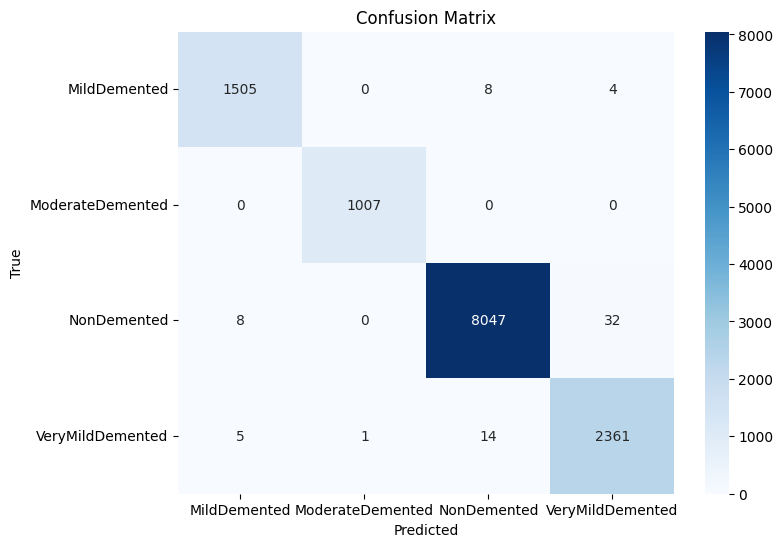

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

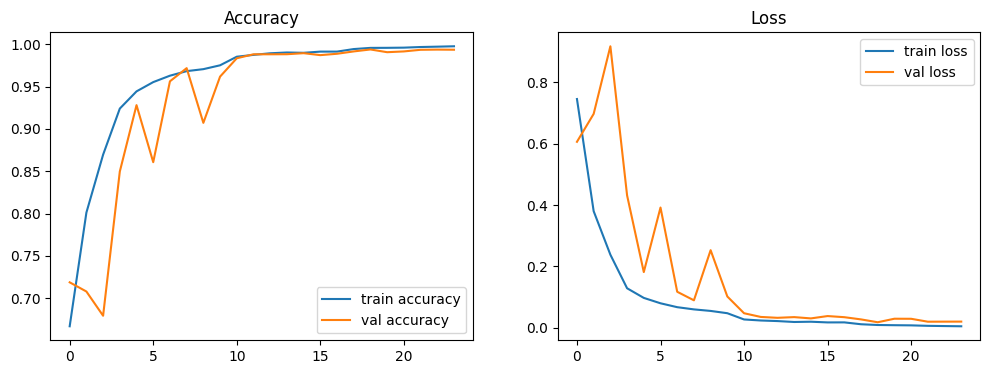

In [18]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="train accuracy")
plt.plot(history.history["val_accuracy"], label="val accuracy")
plt.legend()
plt.title("Accuracy")

plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="train loss")
plt.plot(history.history["val_loss"], label="val loss")
plt.legend()
plt.title("Loss")

plt.show()

In [19]:
model.save("mri_dementia_cnn2.keras")